In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import sys
import pickle
import os

# sys.path.append('/Users/nmehlman/Library/Mobile Documents/com~apple~CloudDocs/Desktop/CSCI 699/Project/poison-perf')
cwd = os.getcwd()
root = os.path.dirname(cwd)
sys.path.append(root)

from utils.algorithms import RGD, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_nd
from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from poisoning.white_box import white_box_poison_function
from poisoning.black_box import black_box_poison_naive, black_box_poison_cluster, black_box_poison_orthogonal
from utils.plotting import plot_results_1d, plot_results_2d

# 10-Dimensional Non-Convex / RGD

In [8]:
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(perfGD=True)

# Hyperparameters
n = 500
eta = 0.02
max_iter = 200
normalize_grad = True
delta = 1.0
epsilon_vals = np.linspace(0.1, 1.0, 10)
poison_step_size = 0.1
norm = 'linf'
n_trials_per_eps = 10

In [9]:
# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_eps):
    theta_clean, _, all_losses_clean = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    normalize_grad=normalize_grad
        )

    theta_clean_avg.append(theta_clean)
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg)
loss_clean = np.mean(loss_clean_avg)

## Black Box Attack

In [10]:
losses_poisoned, theta_poisoned = [], []

for epsilon in tqdm.tqdm(epsilon_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=black_box_poison_orthogonal,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "epsilon_vals": epsilon_vals,
}

pickle.dump(results, open(f'../exports/eps_sweep/non-convex_RGD_black_box.pkl', 'wb'))

100%|██████████| 10/10 [00:12<00:00,  1.28s/it]


## White Box Attack

In [11]:
losses_poisoned, theta_poisoned = [], []

for epsilon in tqdm.tqdm(epsilon_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "epsilon_vals": epsilon_vals,
}

pickle.dump(results, open(f'../exports/eps_sweep/non-convex_RGD_white_box.pkl', 'wb'))

100%|██████████| 10/10 [03:58<00:00, 23.83s/it]


## Oracle Attack

In [12]:
losses_poisoned, theta_poisoned = [], []

for epsilon in tqdm.tqdm(epsilon_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    poison_function=oracle_poison_function,
                    theta_update_estimator=RGD_update_estimator,
                    sampling_estimator=gaussian_sampling_estimator,
                    sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                    poison_steps=int(float(delta)//poison_step_size) + 1,
                    poison_step_size=poison_step_size,
                    epsilon=epsilon,
                    delta=delta,
                    return_losses=True,
                    norm=norm,
                    normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "epsilon_vals": epsilon_vals,
}

pickle.dump(results, open(f'../exports/eps_sweep/non-convex_RGD_oracle.pkl', 'wb'))

100%|██████████| 10/10 [03:52<00:00, 23.22s/it]


## Plots

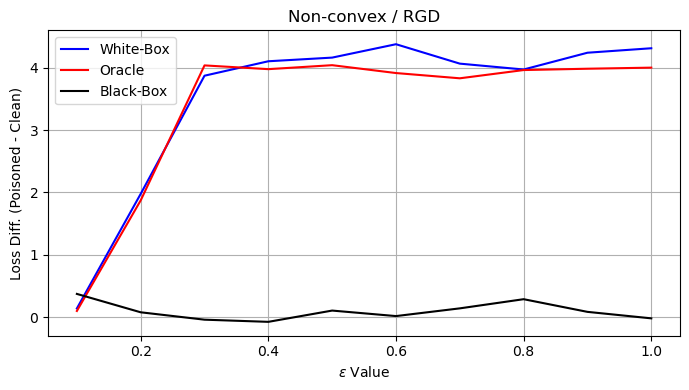

In [13]:
white_box_data = pickle.load(open('../exports/eps_sweep/non-convex_RGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/eps_sweep/non-convex_RGD_oracle.pkl', 'rb'))
black_box_data = pickle.load(open('../exports/eps_sweep/non-convex_RGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(1, 1, figsize=(7, 4), sharex=True)

# Top: loss difference
axes.plot(white_box_data["epsilon_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes.plot(oracle_data["epsilon_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
axes.plot(black_box_data["epsilon_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes.set_ylabel("Loss Diff. (Poisoned - Clean)")
axes.set_title("Non-convex / RGD")
axes.legend()
axes.grid(True)
axes.set_xlabel(r"$\epsilon$ Value")
plt.tight_layout()
plt.show()